In [6]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

np.printoptions()

# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})
N = 100
L = 300

# number of states and around the specific energy (sigma)
num_v_bands_2, sigma_v2 = 250, -0.55
num_v_bands_1, sigma_v1 = 20, 0
num_c_bands, sigma_c = 2, 0.65

wb = np.load("bulk_levels.npy")

paired_splitting_data_N100_numv2_250_v2_-0.55_numv1_20_v1_0_numcb_2_c_0.65.dat: , exported.


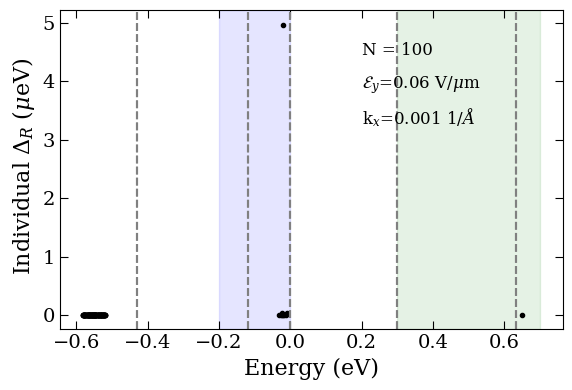

In [7]:

prefactor = 0.001 * 0.5e-5
threshold = 0.1
enr_r, m11_r, m12_r, m21_r, m22_r = np.loadtxt(f'matrix_elements_H11_r_N{N}_numv2_{num_v_bands_2}_v2_{sigma_v2}_numv1_{num_v_bands_1}_v1_{sigma_v1}_numcb_{num_c_bands}_c_{sigma_c}.dat',unpack=True)
enr_i, m11_i, m12_i, m21_i, m22_i = np.loadtxt(f'matrix_elements_H11_i_N{N}_numv2_{num_v_bands_2}_v2_{sigma_v2}_numv1_{num_v_bands_1}_v1_{sigma_v1}_numcb_{num_c_bands}_c_{sigma_c}.dat',unpack=True)


splitting_value = []

for i in range(num_v_bands_2+num_v_bands_1+num_c_bands - 2):

    # Individual contribution from state i
    H_i = (
        np.array([
            [m11_r[i], m12_r[i]],
            [m21_r[i], m22_r[i]]
        ])
        +
        1j * np.array([
            [m11_i[i], m12_i[i]],
            [m21_i[i], m22_i[i]]
        ])
    )

    

    # Diagonalize
    w = eigh(prefactor * H_i, eigvals_only=True)

    gap = np.abs(w[1] - w[0]) * 1e6

    splitting_value.append([enr_r[i], gap])

splitting_value = np.array(splitting_value)
splitting_data_vb = splitting_value[splitting_value[:,0]<0][::-1]
splitting_data_cb = splitting_value[splitting_value[:,0]>0]
splitting_data = np.concatenate((splitting_data_vb, splitting_data_cb ))


# --- Sum Kramers pairs (consecutive rows): (1,2), (3,4), ... ---
# Trim to an even length just in case, then sum only the gap column
n_pairs = len(splitting_data) // 2
energies = splitting_data[:2*n_pairs, 0]
gaps     = splitting_data[:2*n_pairs, 1]

paired_energy = energies[0::2]                 # energy of first of each pair (kept for x-axis)
paired_gap    = gaps[0::2] + gaps[1::2]         # sum of the two Kramers partners' splittings

splitting_data = np.column_stack((paired_energy, paired_gap))

np.savetxt(f"paired_splitting_data_N{N}_numv2_{num_v_bands_2}_v2_{sigma_v2}_numv1_{num_v_bands_1}_v1_{sigma_v1}_numcb_{num_c_bands}_c_{sigma_c}.dat",splitting_data)
print(f"paired_splitting_data_N{N}_numv2_{num_v_bands_2}_v2_{sigma_v2}_numv1_{num_v_bands_1}_v1_{sigma_v1}_numcb_{num_c_bands}_c_{sigma_c}.dat: , exported.")
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(splitting_data[:, 0], splitting_data[:, 1],
        'o', color='black', label='Rashba Splitting', markersize=3)

ax.axvspan(-0.2, 0, color='blue', alpha=0.1)
ax.axvspan(0.3, 0.7, color='green', alpha=0.1)

ax.set_xlabel("Energy (eV)", fontsize=16)
ax.set_ylabel(r" Individual $\Delta_R$ ($\mu$eV)", fontsize=16)
# ax.set_title(r"Saturation Curve: kx=0.001, Ey=0.06 V/$\mu$m", fontsize=16)
ax.text(0.6, 0.7, r"k$_x$=0.001 $1/\AA$",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

ax.text(0.6, 0.8, r"$\mathcal{E}_y$=0.06 V/$\mu$m",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')

ax.text(0.6, 0.9, f"N = {N}",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top')



# Optional second text (if needed)
# ax.text(0.6, 0.07, fr"L = {int(L/10)} nm",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# vertical lines
for i in wb:
    ax.axvline(x=i, linestyle='--', color='gray')

# ax.set_xlim(-0.2, 0.7)
# ax.axhline(y=threshold, linestyle='--')
                                                                                                                                  
ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               labelsize=14)
# ax.grid(True, alpha=0.3)

# ax.legend(fontsize=14)
fig.tight_layout()
plt.savefig("gap_from_individual_matrix_elements.png",dpi = 300)
plt.savefig("gap_from_individual_matrix_elements.pdf",dpi = 300)

plt.show()

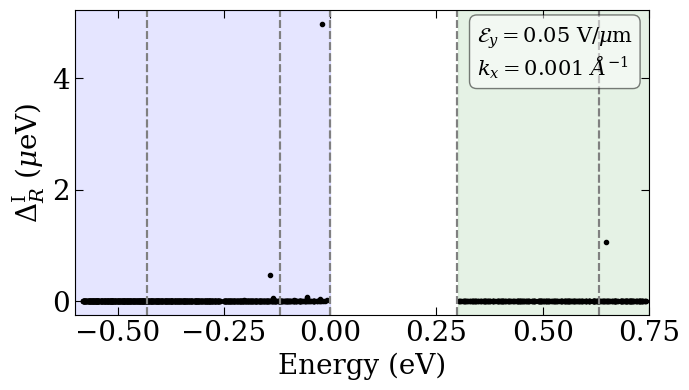

In [8]:
cb_levels = [0.3, 0.5, 0.65]

# =========================
# Load CB data
# =========================
all_cb_data = []

for cb in cb_levels:
    filename = f"paired_splitting_data_N{N}_numv2_2_v2_-0.1_numv1_20_v1_0_numcb_250_c_{cb}.dat"
    data = np.loadtxt(filename)
    all_cb_data.append(data)

# Stack all CB data
combined_cb_data = np.vstack(all_cb_data)
# print(combined_data[combined_data[:,0]>0])


vb_levels = [0]
# =========================
# Load VB data
# =========================
all_vb_data = []

for vb in vb_levels:
    filename = f"paired_splitting_data_N{N}_numv2_2_v2_-0.1_numv1_250_v1_0_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data.append(data)

# Stack all VB data
combined_vb_data = np.vstack(all_vb_data)


vb_levels_2 = [-0.2, -0.3, -0.35, -0.4, -0.45, -0.5, -0.55]
# =========================
# Load VB data
# =========================
all_vb_data_2 = []

for vb in vb_levels_2:
    filename = f"paired_splitting_data_N{N}_numv2_250_v2_{vb}_numv1_20_v1_0_numcb_2_c_0.65.dat"
    data = np.loadtxt(filename)
    all_vb_data_2.append(data)

# Stack all VB data
combined_vb_data_2 = np.vstack(all_vb_data_2)




# # =========================
# # Stack CB + VB data together
# # =========================
combined_data = np.vstack([combined_cb_data, combined_vb_data, combined_vb_data_2])

# Sort by energy column
combined_data = combined_data[np.argsort(combined_data[:, 0])]

# Remove repeated energy values
rounded_energy = np.round(combined_data[:, 0], decimals=10)
_, unique_indices = np.unique(rounded_energy, return_index=True)

clean_data = combined_data[unique_indices]

# Sort again after removing duplicates
clean_data = clean_data[np.argsort(clean_data[:, 0])]


# Save final joined file
np.savetxt(
    f"paired_splitting_data_joined_N{N}_y.dat",
    clean_data,
    fmt="%.10e",
    header="Energy    MatrixElement"
)



fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(clean_data[:, 0], clean_data[:, 1],
        'o', color='black', label='Rashba Splitting', markersize=3)

# ax.plot(splitting_data_vb[:, 0], splitting_data_vb[:, 1],
#         '-', color='black', label='Rashba Splitting', markersize=3)
# ax.plot(splitting_data_cb[:, 0], splitting_data_cb[:, 1],
#         '-', color='black', label='Rashba Splitting', markersize=3)

ax.axvspan(-0.6, 0, color='blue', alpha=0.1)
ax.axvspan(0.3, 0.75, color='green', alpha=0.1)

ax.set_xlabel("Energy (eV)", fontsize=20)
ax.set_ylabel(r"$\Delta^\mathrm{I}_R$ ($\mu$eV)", fontsize=20)
# ax.set_title(r"Saturation Curve: kx=0.001, Ey=0.06 V/$\mu$m", fontsize=16)
# =========================
# Text box
# =========================
textstr = (
    r"$\mathcal{E}_y = 0.05$ V/$\mu$m" + "\n" +
    r"$k_x = 0.001$ $\AA^{-1}$"
)

ax.text(
    0.7, 0.95, textstr,
    transform=ax.transAxes,
    fontsize=15,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.5
    )
)

# ax.text(0.6, 0.9, f"N = {N}",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')



# Optional second text (if needed)
# ax.text(0.6, 0.07, fr"L = {int(L/10)} nm",
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

# vertical lines
for i in wb:
    ax.axvline(x=i, linestyle='--', color='gray')

ax.set_xlim(-0.6, 0.75)
# ax.axhline(y=threshold, linestyle='--')

ax.tick_params(axis='both',
               which='major',
               direction='in',
               top=True,
               right=True,
               length=6,
               labelsize=20)
# ax.grid(True, alpha=0.3)

# ax.legend(fontsize=14)
fig.tight_layout()
# plt.savefig("gap_from_individual_matrix_elements.png",dpi = 300)
plt.savefig("gap_from_individual_matrix_elements.pdf",dpi = 300)

plt.show()
